In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Load the processed data we saved earlier
# Make sure the path matches your folder structure!
data = pd.read_csv("../data/processed/cleaned_financial_data.csv", index_col=0, parse_dates=True)

# 2. Focus on our three assets: TSLA, BND, and SPY
# We calculate 'Daily Returns' because we want to know the % change, not just the price
returns = data.pct_change().dropna()

print("Data loaded and returns calculated successfully!")
print(returns.head())

Data loaded and returns calculated successfully!
                 BND       SPY      TSLA
Date                                    
2015-01-05  0.002904 -0.018060 -0.042041
2015-01-06  0.002895 -0.009419  0.005664
2015-01-07  0.000602  0.012462 -0.001562
2015-01-08 -0.001563  0.017745 -0.001564
2015-01-09  0.001686 -0.008013 -0.018802


In [4]:
# 1. Average yearly return for each stock
annual_returns = returns.mean() * 252

# 2. Annualized 'Risk' (Covariance) 
# This shows how much the stocks wiggle and how they wiggle together
cov_matrix = returns.cov() * 252

print("\n--- Yearly Expected Returns ---")
print(annual_returns)


--- Yearly Expected Returns ---
BND     0.020434
SPY     0.142850
TSLA    0.474914
dtype: float64


In [5]:
# 1. Define how many simulations to run
num_portfolios = 5000

# 2. Create "containers" to store the results
all_weights = np.zeros((num_portfolios, len(returns.columns)))
ret_arr = np.zeros(num_portfolios)
vol_arr = np.zeros(num_portfolios)
sharpe_arr = np.zeros(num_portfolios)

print("Starting simulation... please wait a few seconds.")

for i in range(num_portfolios):
    # Create random weights for BND, SPY, and TSLA
    weights = np.array(np.random.random(3))
    # Important: Rebalance weights so they sum to exactly 1.0 (100%)
    weights = weights / np.sum(weights)
    all_weights[i,:] = weights

    # Calculate Expected Portfolio Return
    ret_arr[i] = np.sum((returns.mean() * weights) * 252)

    # Calculate Expected Portfolio Volatility (Risk)
    # This uses fancy matrix math to see how the assets move together
    vol_arr[i] = np.sqrt(np.dot(weights.T, np.dot(returns.cov() * 252, weights)))

    # Calculate Sharpe Ratio (Return / Risk)
    # We assume a 0% risk-free rate for simplicity
    sharpe_arr[i] = ret_arr[i] / vol_arr[i]

print("Simulation complete!")

# Find the best one!
max_sharpe_idx = sharpe_arr.argmax()
print(f"\n--- Maximum Sharpe Ratio Found: {sharpe_arr[max_sharpe_idx]:.2f} ---")

Starting simulation... please wait a few seconds.
Simulation complete!

--- Maximum Sharpe Ratio Found: 0.99 ---



--- OPTIMAL PORTFOLIO WEIGHTS ---
BND (Bonds):   58.96%
SPY (S&P 500): 30.36%
TSLA (Tesla):  10.69%


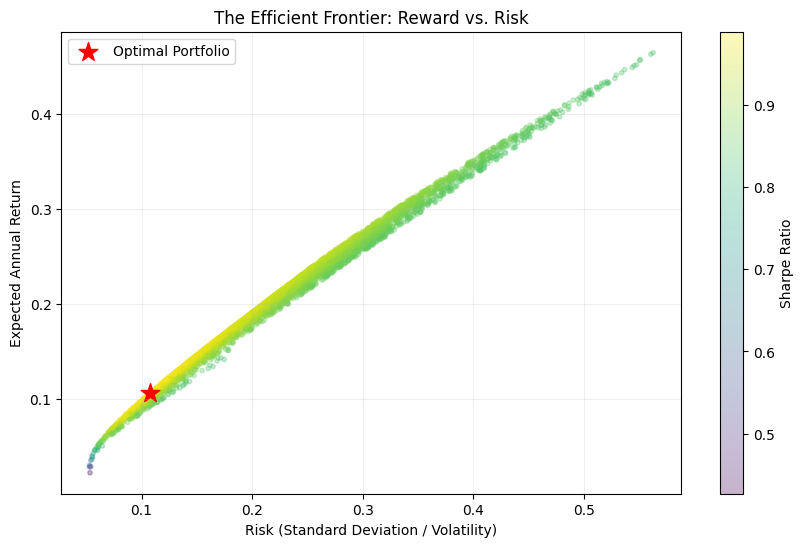

In [6]:
# 1. Extract the best weights found in the simulation
best_weights = all_weights[max_sharpe_idx, :]

print("\n--- OPTIMAL PORTFOLIO WEIGHTS ---")
print(f"BND (Bonds):   {best_weights[0]:.2%}")
print(f"SPY (S&P 500): {best_weights[1]:.2%}")
print(f"TSLA (Tesla):  {best_weights[2]:.2%}")

# 2. Visualize the "Efficient Frontier"
plt.figure(figsize=(10, 6))

# Plot all 5,000 simulations
# 'c' colors them by Sharpe Ratio so we can see the "hottest" areas
plt.scatter(vol_arr, ret_arr, c=sharpe_arr, cmap='viridis', marker='o', s=10, alpha=0.3)
plt.colorbar(label='Sharpe Ratio')

# Highlight the "Winner" with a Red Star
plt.scatter(vol_arr[max_sharpe_idx], ret_arr[max_sharpe_idx], color='red', marker='*', s=200, label='Optimal Portfolio')

plt.title('The Efficient Frontier: Reward vs. Risk')
plt.xlabel('Risk (Standard Deviation / Volatility)')
plt.ylabel('Expected Annual Return')
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

In [7]:
# 1. Calculate Daily Portfolio Returns using the Optimal Weights
# We multiply each stock's daily return by its weight
portfolio_daily_returns = (returns * best_weights).sum(axis=1)

# 2. Calculate the 5th Percentile (95% Confidence VaR)
# This finds the "cutoff point" where the worst 5% of days begin
var_95 = np.percentile(portfolio_daily_returns, 5)

print(f"\n--- Risk Analysis ---")
print(f"95% Daily Value at Risk (VaR): {var_95:.2%}")

# Interpretation
print(f"Interpretation: There is a 95% chance that the portfolio will")
print(f"NOT lose more than {abs(var_95):.2%} of its value in a single day.")


--- Risk Analysis ---
95% Daily Value at Risk (VaR): -1.02%
Interpretation: There is a 95% chance that the portfolio will
NOT lose more than 1.02% of its value in a single day.
